# Sampling NLA Shape Surfaces for Compression

This notebook turns one frozen 13-parameter NLA shape prior into a validated dataset for PCA and neural compression. It maps unit-cube draws to physical parameters, tests both the random population and every prior corner, and writes 100,000 surfaces on a $31\times101$ redshift--wavenumber grid. The resulting HDF5 file fixes the samples and data splits used by all later compression models.

## Compression Target and Parameterisation

We separate the signed IA amplitude into

$$\mathcal A_{\rm IA}(k,z)=-A_0\,\mathcal A_\Omega(z)\,\mathcal A_\Theta(k,z),\qquad \mathcal A_\Theta=R_zR_LS>0.$$

The scale-dependent response is

$$S(k,z)=1+q\,\frac{x^{n(z)}}{1+x^{n(z)}}\left[\frac{1+x^{m(z)}}{2}\right]^{\alpha(z)/m(z)},\qquad x=\frac{k}{k_t(z)},$$

with $k_t(z)=k_t^\ast r_\ast^{\gamma_{k_t}}$, $n(z)=n^\ast r_\ast^{\gamma_n}$, $\alpha(z)=\alpha^\ast r_\ast^{\gamma_\alpha}$, $m(z)=m^\ast r_\ast^{\gamma_m}$, and $r_\ast=(1+z)/(1+z_\ast)$. Together with the redshift and luminosity factors, this gives

$$\boldsymbol\Theta_{\rm shape}=(\eta,\xi,s,z_q,q,n^\ast,k_t^\ast,\alpha^\ast,m^\ast,\gamma_{k_t},\gamma_n,\gamma_\alpha,\gamma_m).$$

The exact scalar $A_0$ is not sampled or compressed; it is restored analytically after decompression. The recommended learning target is $\log_{10}\mathcal A_\Theta$, which is defined everywhere because the surface is positive.

In [1]:
import json
import sys
from pathlib import Path

import h5py
import numpy
from matplotlib import pyplot

In [2]:
pyplot.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 18,
    "text.usetex": True,
})
colour_list = ["red", "orange", "black", "blue", "purple"]

In [ ]:
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "pyproject.toml").is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Run this notebook from within the IAFlowCloud repository.")
    PROJECT_ROOT = PROJECT_ROOT.parent

code_path = PROJECT_ROOT / "Code"
if str(code_path) not in sys.path:
    sys.path.insert(0, str(code_path))

data_path = PROJECT_ROOT / "Data" / "NLA" / "Samples"
figure_path = PROJECT_ROOT / "Figure" / "NLA" / "Sampling"
data_path.mkdir(parents=True, exist_ok=True)
figure_path.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_ROOT)
print("Dataset directory:", data_path)
print("Figure directory: ", figure_path)


Project directory: /Users/s2227120/IAFlowCloud
Dataset directory: /Users/s2227120/IAFlowCloud/Data/NLA/Samples
Figure directory:  /Users/s2227120/IAFlowCloud/Figure/NLA/Sampling


In [4]:
from ia_models.general.data_split import build_dataset_split_indices
from ia_models.nla.model import Z_STAR, NLAModel
from ia_models.nla.sampling import (
    DEFAULT_SELECTION_CRITERIA,
    combine_positive_model_factors,
    evaluate_prior_candidate,
    generate_unit_samples,
    get_final_prior,
    save_nuisance_dataset_in_batches,
    transform_unit_samples,
    validate_generated_dataset,
)


## Sampling Coordinates and Frozen Prior

| Space | Shape in this notebook | Meaning |
|---|---:|---|
| Unit cube | `(N, 13)` | dimensionless values in $[0,1]$ |
| Parameter space | `(N, 13)` | physical/model parameter values |
| Surface space | `(N, 31, 101)` | $S(k,z)$ and $\mathcal A_\Theta(k,z)$ |

The training prior is a coverage rule for the compressor, not an observational posterior. It should retain useful physical variation without allowing a tiny population of extreme surfaces to dominate the loss. Uniform parameters use $\theta=\theta_{\min}+u(\theta_{\max}-\theta_{\min})$; $k_t^\ast$ is log-uniform because multiplicative changes are natural for a positive scale. The code below prints the authoritative bounds.

### Evaluation Grid and Reproducibility

The grid uses 31 redshift slices from $z=0$ to $3$ in steps of 0.1 and 101 logarithmic wavenumbers from $10^{-2}$ to $10^1\,{\rm Mpc}^{-1}$. Fixed, separate seeds make validation draws, production draws, and data splits reproducible without coupling them.

In [5]:
validation_random_seed = 2026
production_random_seed = 2027
split_random_seed = 2028
validation_number_of_models = 8192
final_number_of_models = 100000
generation_batch_size = 2048
REBUILD_PRODUCTION_DATA = False  # Change deliberately; generation replaces a 1.6 GiB file.

z_training = numpy.linspace(0.0, 3.0, 31)
k_training = numpy.logspace(-2, 1, 101)
final_prior = get_final_prior()
selection_criteria = dict(DEFAULT_SELECTION_CRITERIA)
parameter_names = list(NLAModel.SHAPE_PARAMETER_NAMES)

assert len(parameter_names) == 13
assert "A0" not in parameter_names
assert tuple(final_prior) == tuple(parameter_names)
assert numpy.allclose(numpy.diff(z_training), 0.1)

print("Shape parameters:", parameter_names)
print("Training grid:   ", (len(z_training), len(k_training)))
print("Final models:    ", f"{final_number_of_models:,}")

Shape parameters: ['eta', 'xi', 's', 'z_q', 'q', 'n_star', 'k_t_star', 'alpha', 'm', 'gamma_t', 'gamma_n', 'gamma_alpha', 'gamma_m']
Training grid:    (31, 101)
Final models:     100,000


In [6]:
print(f"{'Parameter':16s} {'Minimum':>10s} {'Maximum':>10s} {'Rule':>14s}")
print("-" * 54)
for name, specification in final_prior.items():
    print(
        f"{name:16s} {specification['minimum']:10.3g} "
        f"{specification['maximum']:10.3g} {specification['distribution']:>14s}"
    )

Parameter           Minimum    Maximum           Rule
------------------------------------------------------
eta                    -1.5        1.5        uniform
xi                     -1.5        1.5        uniform
s                         1         10        uniform
z_q                     0.5        2.5        uniform
q                         0          2        uniform
n_star                    1          5        uniform
k_t_star                0.1          1    log_uniform
alpha                  -0.4        0.4        uniform
m                         1          4        uniform
gamma_t                -0.5        0.5        uniform
gamma_n               -0.35       0.35        uniform
gamma_alpha           -0.25       0.25        uniform
gamma_m                -0.2        0.2        uniform


## Validation Across the Prior

**Random validation** samples 8192 interior points from the actual training distribution. It describes typical dynamic ranges, rare population tails, pointwise diversity, and nonlinear behaviour that need not occur at a boundary.

**Corner validation** evaluates all $2^{13}=8192$ simultaneous lower/upper endpoint combinations. It is a deterministic stress test for reinforcing parameter interactions, such as strong redshift evolution combined with an early transition and a rising high-$k$ tail.

Neither test replaces the other. If the outer 5% at either end counts as near an endpoint, one random draw reaches an endpoint region in all 13 dimensions with probability

$$(0.10)^{13}=10^{-13}.$$

Thus random draws will not reproduce the full boundary test, while corners do not represent the density or diversity of the training population. The prior is accepted only when both views pass.

In [7]:
validation_unit_samples = generate_unit_samples(
    validation_number_of_models,
    validation_random_seed,
)
final_evaluation = evaluate_prior_candidate(
    "final_prior",
    final_prior,
    validation_unit_samples,
    z_training,
    k_training,
    criteria=selection_criteria,
)
final_summary = final_evaluation["summary"]
final_assessment = final_evaluation["assessment"]
print(json.dumps(final_summary, indent=2))
print(json.dumps(final_assessment, indent=2))

{
  "candidate": "final_prior",
  "number_of_random_models": 8192,
  "valid_fraction": 1.0,
  "median_log_dynamic_range": 0.7951077950253953,
  "q99_log_dynamic_range": 1.655792431124586,
  "maximum_log_dynamic_range": 2.108418689090709,
  "median_pointwise_shape_spread": 1.024954189079113,
  "maximum_pointwise_shape_spread": 2.0291540215906294,
  "number_of_corner_models": 8192,
  "corner_valid_fraction": 1.0,
  "corner_q99_log_dynamic_range": 2.6060434509396875,
  "corner_maximum_log_dynamic_range": 2.958448677325089
}
{
  "random_validity": true,
  "corner_validity": true,
  "random_tail_control": true,
  "corner_tail_control": true,
  "shape_diversity": true,
  "accepted": true
}


### Acceptance Diagnostics

Every surface must be finite and positive, with $k_t(z)>0$, $n(z)>0$, and $m(z)>0$. For model $i$,

$$D_i=\max_{z,k}\log_{10}\mathcal A_{\Theta,i}-\min_{z,k}\log_{10}\mathcal A_{\Theta,i}$$

measures its internal dynamic range in dex. The random $Q_{99}(D)$ limits the rare tail of the sampled population, while the maximum corner $D$ limits the hardest allowed endpoint interaction. The median pointwise 1--99% spread requires useful ensemble diversity at typical $(z,k)$ locations.

| Gate | Requirement |
|---|---:|
| Random and corner validity | $100\%$ |
| Random $Q_{99}(D)$ | $\leq1.75$ dex |
| Maximum corner $D$ | $\leq3.00$ dex |
| Median pointwise spread | $\geq1.00$ dex |

These are transparent design choices for this first compression experiment, not observational constraints or universal laws of IA physics.

In [8]:
metric_rows = [
    ("Random validity", final_summary["valid_fraction"], selection_criteria["minimum_random_valid_fraction"]),
    ("Corner validity", final_summary["corner_valid_fraction"], selection_criteria["minimum_corner_valid_fraction"]),
    ("Random Q99 D [dex]", final_summary["q99_log_dynamic_range"], selection_criteria["maximum_random_q99_log_dynamic_range"]),
    ("Corner maximum D [dex]", final_summary["corner_maximum_log_dynamic_range"], selection_criteria["maximum_corner_log_dynamic_range"]),
    ("Median pointwise spread [dex]", final_summary["median_pointwise_shape_spread"], selection_criteria["minimum_median_pointwise_shape_spread"]),
]
print(f"{'Metric':34s} {'Measured':>12s} {'Threshold':>12s}")
print("-" * 62)
for name, measured, threshold in metric_rows:
    print(f"{name:34s} {measured:12.4f} {threshold:12.4f}")

Metric                                 Measured    Threshold
--------------------------------------------------------------
Random validity                          1.0000       1.0000
Corner validity                          1.0000       1.0000
Random Q99 D [dex]                       1.6558       1.7500
Corner maximum D [dex]                   2.9584       3.0000
Median pointwise spread [dex]            1.0250       1.0000


In [9]:
assert final_assessment["accepted"]
assert not final_evaluation["failures"]
assert not final_evaluation["corner_failures"]
assert final_summary["number_of_random_models"] == 8192
assert final_summary["number_of_corner_models"] == 2 ** 13
validate_generated_dataset(
    final_evaluation["parameters"],
    final_evaluation["components"],
    final_evaluation["valid_mask"],
    final_prior,
    z_training,
    k_training,
)
assert numpy.allclose(
    final_evaluation["components"]["A_theta"],
    combine_positive_model_factors(final_evaluation["components"]),
)
print("The frozen prior passed all random and corner checks.")

The frozen prior passed all random and corner checks.


### Validated Prior

The frozen prior passes every gate:

| Diagnostic | Measured | Requirement |
|---|---:|---:|
| Random validity | $1.000$ | $1.000$ |
| Corner validity | $1.000$ | $1.000$ |
| Random $Q_{99}(D)$ | $1.656$ dex | $\leq1.750$ dex |
| Maximum corner $D$ | $2.958$ dex | $\leq3.000$ dex |
| Median pointwise spread | $1.025$ dex | $\geq1.000$ dex |

An earlier trial used $\gamma_\alpha\in[-0.50,0.50]$ and $\gamma_m\in[-0.35,0.35]$ and reached a corner maximum of $3.261$ dex. Keeping the acceptance gates fixed, only those two new evolution ranges were narrowed. The final ranges, $[-0.25,0.25]$ and $[-0.20,0.20]$, retain the required diversity while controlling the boundary stress case.

## Surface Ensemble

The curves below summarize the 8192 random validation models. Quantile bands show the population without drawing thousands of opaque lines; the five largest-$D$ models remain visible as stress examples. Their role is diagnostic: they show which accepted surfaces are hardest to compress, rather than introducing a second rejection rule.

In [10]:
validation_components = final_evaluation["components"]
validation_diagnostics = final_evaluation["diagnostics"]
extreme_indices = numpy.argsort(validation_diagnostics["log_dynamic_range"])[-5:][::-1]

def add_ensemble_summary(plot, coordinate, curves):
    quantiles = numpy.quantile(curves, [0.01, 0.05, 0.5, 0.95, 0.99], axis=0)
    plot.fill_between(coordinate, quantiles[0], quantiles[4], color="blue", alpha=0.12, label=r"$1$--$99\%$")
    plot.fill_between(coordinate, quantiles[1], quantiles[3], color="blue", alpha=0.25, label=r"$5$--$95\%$")
    plot.plot(coordinate, quantiles[2], color="black", linewidth=2.0, label="median")

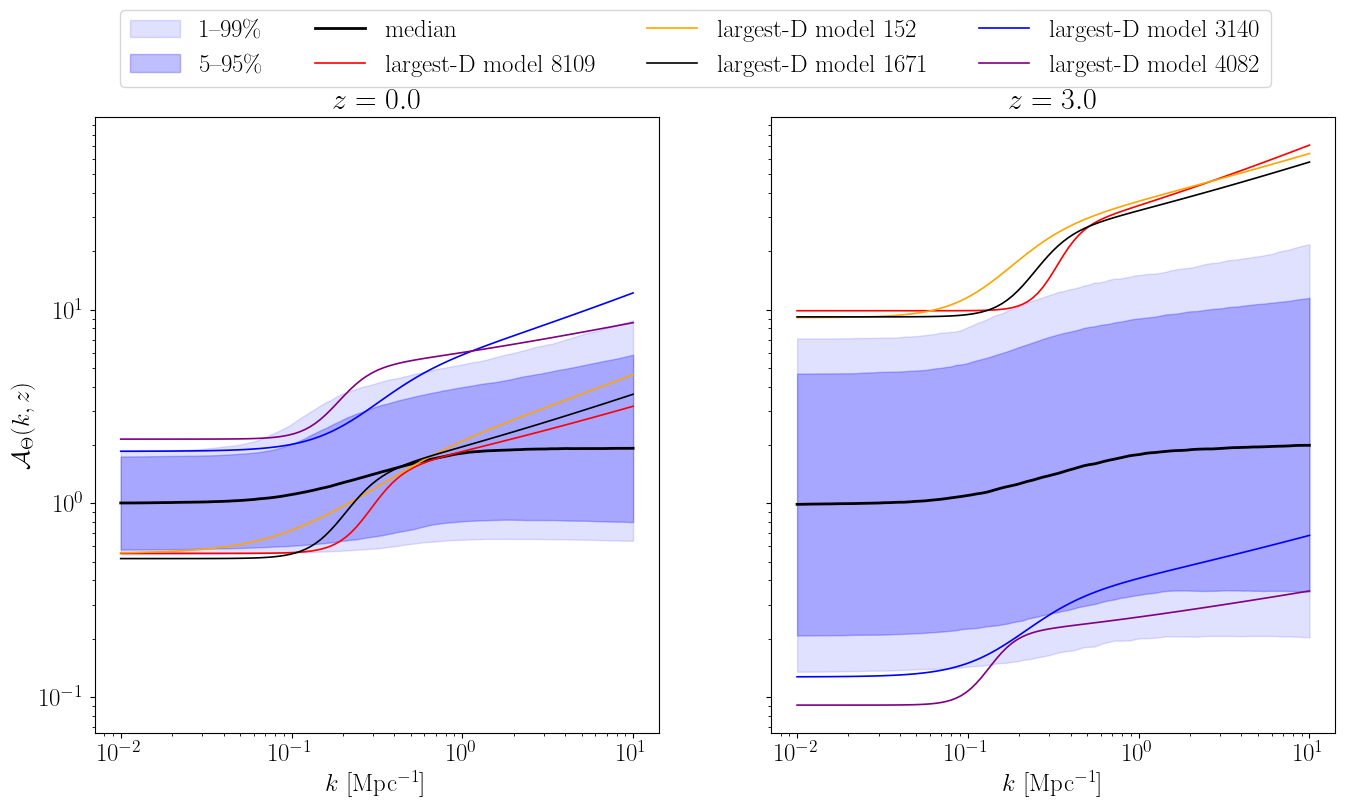

In [11]:
figure, plots = pyplot.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)
for panel_index, (plot, redshift_index) in enumerate(zip(plots, [0, -1])):
    add_ensemble_summary(plot, k_training, validation_components["A_theta"][:, redshift_index, :])
    for colour, model_index in zip(colour_list, extreme_indices):
        label = f"largest-D model {model_index}" if panel_index == 0 else "_nolegend_"
        plot.plot(k_training, validation_components["A_theta"][model_index, redshift_index], color=colour, linewidth=1.2, label=label)
    plot.set_xscale("log")
    plot.set_yscale("log")
    plot.set_xlabel(r"$k$ [Mpc$^{-1}$]")
    plot.set_title(rf"$z={z_training[redshift_index]:.1f}$")
plots[0].set_ylabel(r"$\mathcal A_\Theta(k,z)$")
handles, labels = plots[0].get_legend_handles_labels()
figure.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.03), ncols=4)
figure.savefig(figure_path / "Final_Prior_Amplitude_Ensemble.pdf", dpi=512, bbox_inches="tight")

## Production Dataset

Each surface has 3131 grid values but belongs to a smooth 13-dimensional model manifold, so the sample count need not exceed the number of neural-network weights. The 100,000-model set nevertheless gives enough coverage for architecture comparisons, stable tail diagnostics, and learning curves. It is split once into 80,000 training, 10,000 validation, and 10,000 test rows.

At `float32`, one $(100000,31,101)$ tensor occupies about 1.25 GB before compression. Because we keep both `S_k_z` and `A_theta`, generation is streamed in batches of 2048. The final file is large by design, but peak memory stays controlled.

In [12]:
production_unit_samples = generate_unit_samples(
    final_number_of_models,
    production_random_seed,
)
production_parameters = transform_unit_samples(production_unit_samples, final_prior)
production_split_indices = build_dataset_split_indices(
    final_number_of_models,
    split_random_seed,
)
print("Parameter matrix:", production_parameters.shape)
print("Split sizes:     ", {name: len(indices) for name, indices in production_split_indices.items()})

Parameter matrix: (100000, 13)
Split sizes:      {'train': 80000, 'validation': 10000, 'test': 10000}


In [13]:
production_metadata = {
    "production_random_seed": production_random_seed,
    "split_random_seed": split_random_seed,
    "validation_random_seed": validation_random_seed,
    "number_of_models": final_number_of_models,
    "number_of_shape_parameters": 13,
    "validation_number_of_models": validation_number_of_models,
    "corner_number_of_models": 2 ** 13,
    "generation_batch_size": generation_batch_size,
    "sampling_method": "independent unit-cube samples transformed by the frozen final prior",
    "cosmology_sampled": False,
    "A0_sampled": False,
    "z_star": Z_STAR,
    "k_units": "Mpc^-1",
    "A_theta_definition": "R_z * R_L * S_k_z",
    "A_IA_definition": "-A0 * A_omega * A_theta",
    "recommended_primary_compression_target": "log10(A_theta)",
    "validation_summary": final_summary,
    "validation_assessment": final_assessment,
    "corner_test": "all 2**13 simultaneous lower/upper shape-parameter corners",
    "split_fractions": {"train": 0.80, "validation": 0.10, "test": 0.10},
    "storage_dtype": "float32",
}
production_output_file = data_path / "NLA.hdf5"
if REBUILD_PRODUCTION_DATA:
    production_output_file = save_nuisance_dataset_in_batches(
        production_output_file,
        production_parameters,
        final_prior,
        production_metadata,
        z=z_training,
        k=k_training,
        split_indices=production_split_indices,
        storage_dtype="float32",
        batch_size=generation_batch_size,
        overwrite=True,
    )
    print("Rebuilt:", production_output_file.resolve())
elif not production_output_file.is_file():
    raise FileNotFoundError("Set REBUILD_PRODUCTION_DATA=True to generate NLA.hdf5.")
else:
    print("Reusing validated dataset:", production_output_file.resolve())

Reusing validated dataset: /Users/s2227120/IAFlowCloud/Data/NLA/Samples/NLA.hdf5


### On-Disk Consistency Checks

The checks below confirm the schema, shapes, parameter order, split sizes, and the identity $\mathcal A_\Theta=R_zR_LS$ on selected rows directly from disk. This validates the multi-gigabyte file without loading it fully into memory.

In [14]:
with h5py.File(production_output_file, "r") as saved_dataset:
    saved_names = [name.decode() if isinstance(name, bytes) else name for name in saved_dataset["parameters/names"][:]]
    assert saved_names == parameter_names
    assert "A0" not in saved_names
    assert saved_dataset["parameters/values"].shape == (100000, 13)
    assert saved_dataset["components/S_k_z"].shape == (100000, 31, 101)
    assert saved_dataset["components/A_theta"].shape == (100000, 31, 101)
    check_indices = numpy.array([0, 50000, 99999])
    reconstructed = (
        saved_dataset["components/R_z"][check_indices][:, :, None]
        * saved_dataset["components/R_L"][check_indices][:, :, None]
        * saved_dataset["components/S_k_z"][check_indices]
    )
    assert numpy.allclose(reconstructed, saved_dataset["components/A_theta"][check_indices], rtol=2e-5)
    assert {name: len(saved_dataset[f"splits/{name}"]) for name in ("train", "validation", "test")} == {"train": 80000, "validation": 10000, "test": 10000}
file_size_gib = production_output_file.stat().st_size / 1024**3
print(f"Verified the NLA data contract, including S_k_z. File size: {file_size_gib:.2f} GiB")

Verified the NLA data contract, including S_k_z. File size: 1.50 GiB


## Data Contract for Compression Models

```text
NLA.hdf5
├── coordinates
│   ├── z                    (31,)
│   ├── k                    (101,)
│   └── r_star               (31,)
├── parameters
│   ├── names                (13,), no A0
│   └── values               (100000, 13)
├── components
│   ├── R_z                  (100000, 31)
│   ├── R_L                  (100000, 31)
│   ├── S_k_z                (100000, 31, 101)
│   └── A_theta              (100000, 31, 101)
├── diagnostics             extrema, dynamic range, extreme flag
└── splits                  80000 train, 10000 validation, 10000 test
```

PCA and every neural model must load this same file and use its stored splits. Standardization, PCA fitting, and learned preprocessing use training rows only; validation rows guide model selection, and test rows are reserved for final reporting. The primary input is $\log_{10}\mathcal A_\Theta$. After decompression, the signed amplitude is reconstructed as $\widehat{\mathcal A}_{\rm IA}=-A_0\mathcal A_\Omega\widehat{\mathcal A}_\Theta$. Using identical rows and splits makes PCA, autoencoder, U-Net-style, and later latent-density results directly comparable.

## Final consistency checks


In [15]:
with h5py.File(production_output_file, "r") as saved_dataset:
    assert {"minimum", "maximum", "log_dynamic_range", "extreme_flag"} == set(saved_dataset["diagnostics"])
    assert saved_dataset["diagnostics"].attrs["component"] == "A_theta"
assert production_output_file == data_path / "NLA.hdf5"
print("Sampling notebook consistency checks passed.")


Sampling notebook consistency checks passed.
